In [64]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess, sys

for pkg in ["shap", "lifelines"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
try:
    import shap
    SHAP_AVAILABLE = True
    print("✅ shap available")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠  shap not available — Section C will be skipped")

try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    LIFELINES_AVAILABLE = True
    print("✅ lifelines available")
except ImportError:
    LIFELINES_AVAILABLE = False
    print("⚠  lifelines not available — Section E will be skipped")    
 
from scipy.stats import chi2_contingency, mannwhitneyu, skew as scipy_skew
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

✅ shap available
✅ lifelines available


In [65]:
DATA_PATH   = "/Users/a1466/Documents/Analytics Projects/Telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv" 
RANDOM_SEED = 246
TEST_SIZE   = 0.20
ALPHA       = 0.05   # significance threshold for all statistical tests
PALETTE     = "Set2" # single consistent palette used throughout
 
sns.set_theme(style="whitegrid", palette=PALETTE)

# SECTION 1 — DATA LOADING & CLEANING

In [66]:
df = pd.read_csv(DATA_PATH)
print(f"Raw dataset shape : {df.shape}")
print(f"Columns           : {list(df.columns)}\n")

Raw dataset shape : (7043, 21)
Columns           : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']



In [67]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [68]:
# 1. Drop the customerID column — no predictive or analytical value
df = df.drop(columns=["customerID"])

In [69]:
print(df.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [70]:
# 2. TotalCharges is stored as a string in this dataset; coerce to float.
#    Rows with blank TotalCharges (new customers with 0 tenure) become NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [71]:
# 3. Report and remove the 11 affected rows
missing = df.isnull().sum()
print("Missing values per column after coercion:")
print(missing[missing > 0])
print()
 
df = df.dropna()
print(f"Clean dataset shape: {df.shape}  ({7043 - len(df)} rows removed)\n")

Missing values per column after coercion:
TotalCharges    11
dtype: int64

Clean dataset shape: (7032, 20)  (11 rows removed)



In [72]:
# 4. Print the overall churn rate — key baseline metric
churn_counts = df["Churn"].value_counts()
churn_rate   = churn_counts["Yes"] / len(df) * 100
print(f"Overall churn rate : {churn_rate:.1f}%  "
      f"({churn_counts['Yes']:,} churned / {len(df):,} total)\n")

Overall churn rate : 26.6%  (1,869 churned / 7,032 total)



# SECTION 2 — EXPLORATORY DATA ANALYSIS (EDA)

In [73]:
def add_count_and_pct_labels(ax, total, fontsize=9):
    """Annotate each bar in a countplot with its count and % of total."""
    for bar in ax.patches:
        h = bar.get_height()
        if h == 0:
            continue
        pct = h / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + total * 0.005,          # small offset relative to axis scale
            f"{int(h):,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=fontsize, linespacing=1.4,
        )
 
def add_churn_rate_labels(ax, df, group_col, fontsize=9):
    """
    Annotate the 'Churn = Yes' bars with the within-group churn rate.
    This answers "what % of customers in this group churn?" — a more
    meaningful metric than raw counts when group sizes differ.
    """
    group_totals = df[group_col].value_counts()
    churn_counts = df[df["Churn"] == "Yes"][group_col].value_counts()
 
    for bar in ax.patches:
        h = bar.get_height()
        if h == 0:
            continue
        # Identify which category this bar belongs to by x-position
        x_center  = bar.get_x() + bar.get_width() / 2
        tick_pos  = [t.get_position()[0] for t in ax.get_xticklabels()]
        tick_labs = [t.get_text() for t in ax.get_xticklabels()]
        if not tick_pos:
            continue
        closest   = tick_labs[int(np.argmin([abs(x_center - p) for p in tick_pos]))]
 
        # Only label the Churn=Yes bars (the ones matching churn_counts)
        if closest in churn_counts.index and abs(h - churn_counts[closest]) <= 1:
            rate = churn_counts[closest] / group_totals[closest] * 100
            ax.text(
                x_center, h + group_totals.max() * 0.01,
                f"{rate:.0f}% churn",
                ha="center", va="bottom", fontsize=fontsize,
                color="crimson", fontweight="bold",
            )

## CHART SET 1 — Baseline Churn & Contract Type Impact

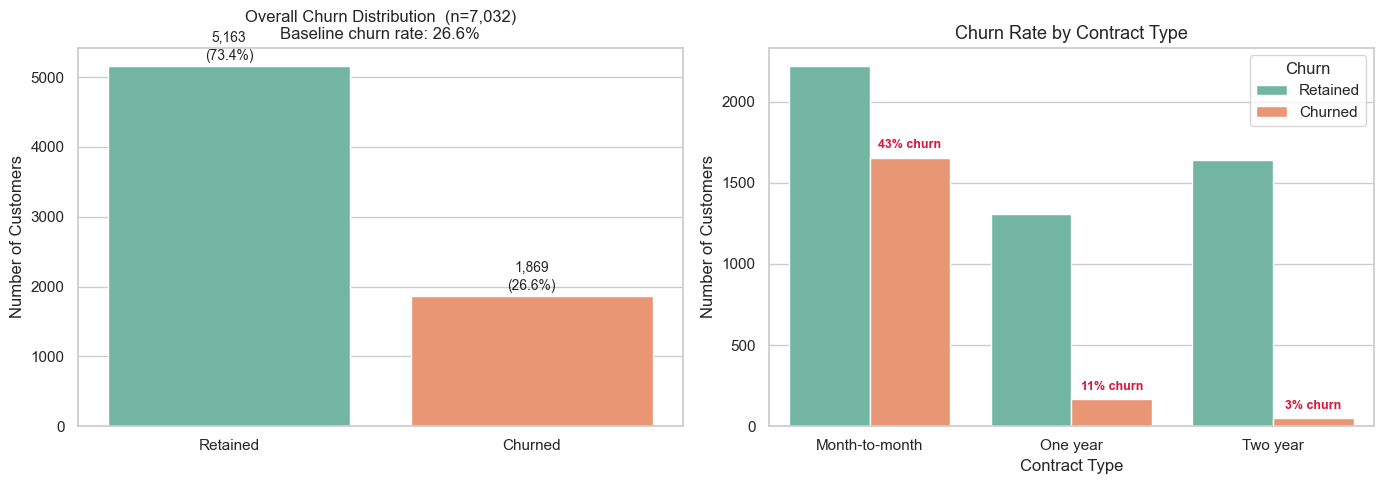

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Chart 1a — Overall churn distribution
sns.countplot(data=df, x="Churn", palette=PALETTE, ax=axes[0])
axes[0].set_title(
    f"Overall Churn Distribution  (n={len(df):,})\n"
    f"Baseline churn rate: {churn_rate:.1f}%",
    fontsize=12,
)
axes[0].set_ylabel("Number of Customers")
axes[0].set_xlabel("")
axes[0].set_xticklabels(["Retained", "Churned"])
add_count_and_pct_labels(axes[0], total=len(df), fontsize=10)
 
# Chart 1b — Churn by contract type
sns.countplot(data=df, x="Contract", hue="Churn", palette=PALETTE, ax=axes[1])
axes[1].set_title("Churn Rate by Contract Type", fontsize=13)
axes[1].set_ylabel("Number of Customers")
axes[1].set_xlabel("Contract Type")
axes[1].legend(title="Churn", labels=["Retained", "Churned"])
add_churn_rate_labels(axes[1], df, "Contract", fontsize=9)
 
plt.tight_layout()
plt.savefig("chart1_churn_contract.png", dpi=150, bbox_inches="tight")
plt.show()

## Business insight:
###   Month-to-month customers churn at a far higher rate than customers on 1-year or 2-year contracts.  Migrating these customers to longer terms through targeted discounts is the single highest-leverage retention lever.

## CHART SET 2 — Financial & Lifespan Drivers (Boxplots)

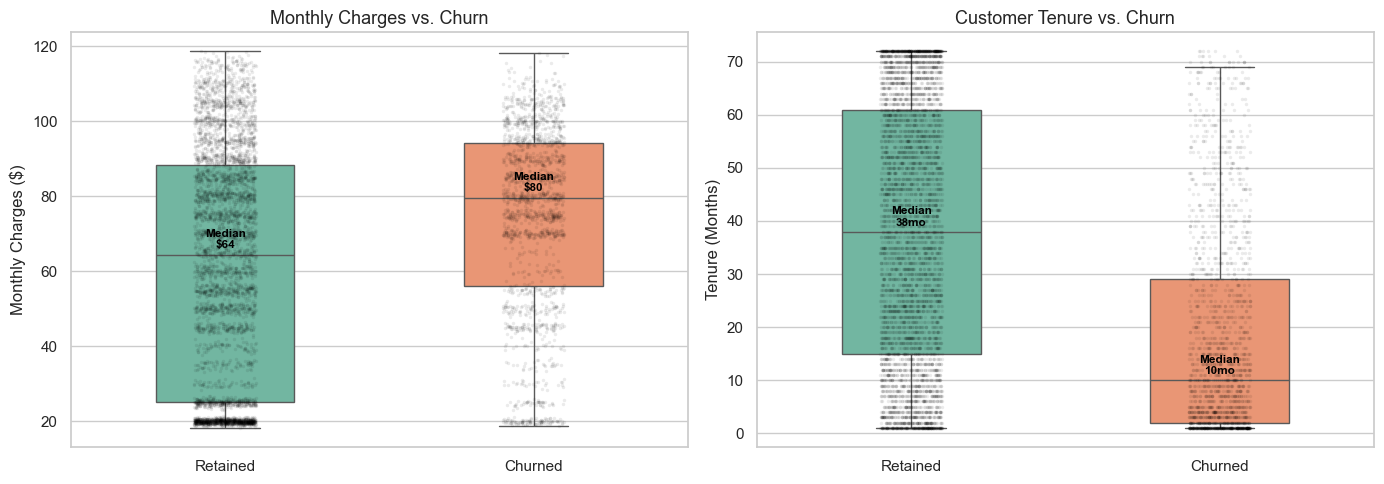

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, col, ylabel, title in [
    (axes[0], "MonthlyCharges", "Monthly Charges ($)",  "Monthly Charges vs. Churn"),
    (axes[1], "tenure",         "Tenure (Months)",      "Customer Tenure vs. Churn"),
]:
    sns.boxplot(
        data=df, x="Churn", y=col, palette=PALETTE,
        width=0.45, fliersize=0, ax=ax,   # fliersize=0: outliers shown by strip
    )
    sns.stripplot(
        data=df, x="Churn", y=col,
        color="black", alpha=0.08, size=2.5, jitter=True, ax=ax,
    )
    # Annotate median value on each box
    for i, group in enumerate(["No", "Yes"]):
        median = df[df["Churn"] == group][col].median()
        ax.text(
            i, median + (df[col].max() * 0.01),
            f"Median\n${median:,.0f}" if col == "MonthlyCharges" else f"Median\n{median:.0f}mo",
            ha="center", va="bottom", fontsize=8.5, color="black", fontweight="bold",
        )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("")
    ax.set_xticklabels(["Retained", "Churned"])
    ax.set_ylabel(ylabel)
 
plt.tight_layout()
plt.savefig("chart2_charges_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

## Business insight:
###   Churners pay *higher* monthly charges but have *shorter* tenures.
###   The first ~12 months is the highest-risk window, early onboarding and
###   targeted discounts during this period are critical retention investments.

## CHART SET 3 — Tenure Distribution by Churn (Histogram)

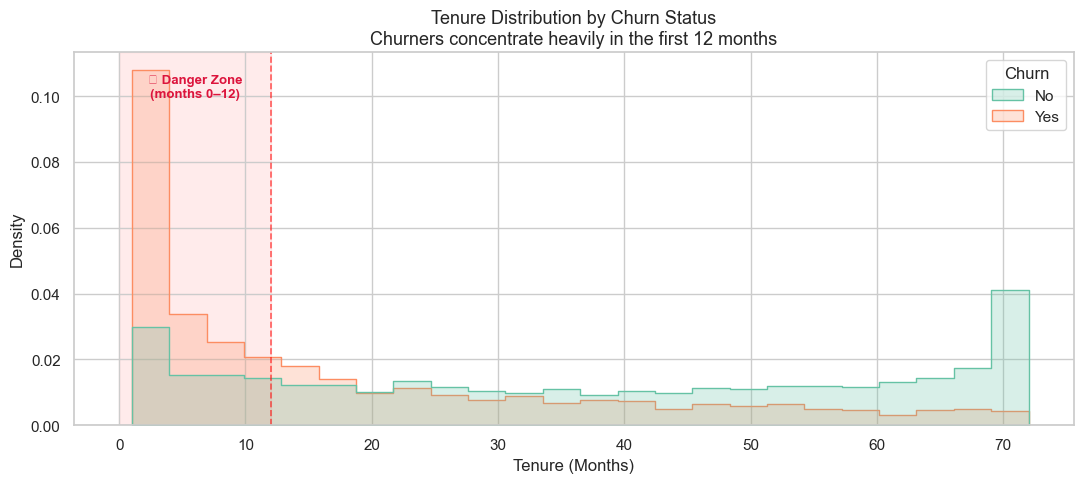

In [76]:
fig, ax = plt.subplots(figsize=(11, 5))
 
sns.histplot(
    data=df, x="tenure", hue="Churn",
    bins=24, palette=PALETTE, element="step",
    stat="density", common_norm=False, ax=ax,
)
 
# Shade and label the early-churn danger zone
ax.axvspan(0, 12, alpha=0.08, color="red", zorder=0)
ax.axvline(12, color="red", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(
    6, ax.get_ylim()[1] * 0.88,
    "⚠ Danger Zone\n(months 0–12)",
    ha="center", fontsize=9.5, color="crimson", fontweight="bold",
)
 
ax.set_title(
    "Tenure Distribution by Churn Status\n"
    "Churners concentrate heavily in the first 12 months",
    fontsize=13,
)
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Density")
 
plt.tight_layout()
plt.savefig("chart3_tenure_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## CHART SET 4 — Internet Service & Tech Support Impact

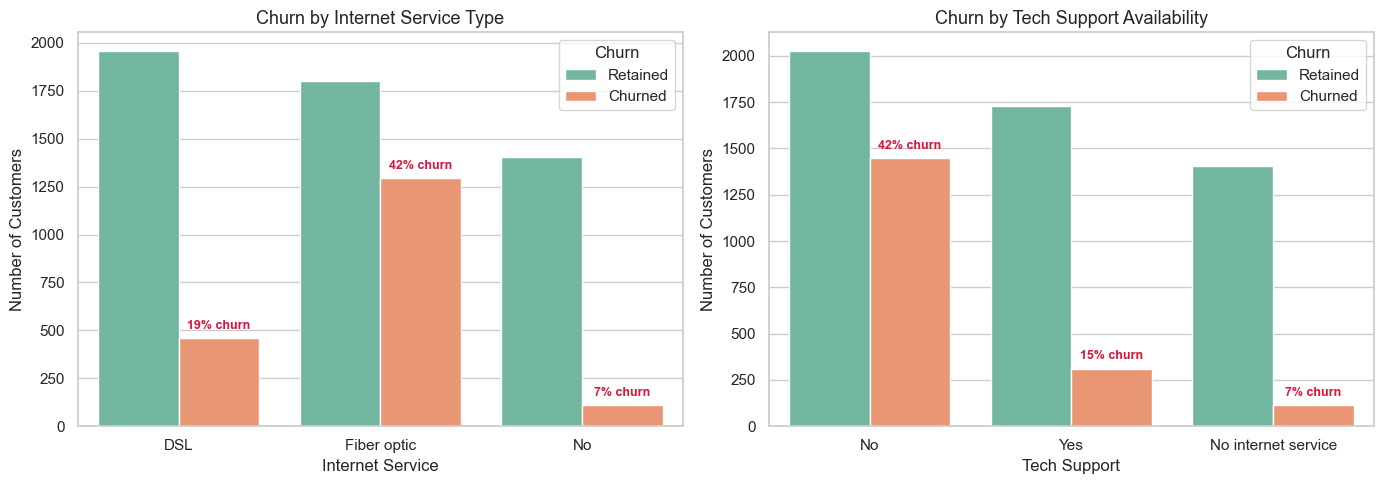

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.countplot(data=df, x="InternetService", hue="Churn", palette=PALETTE, ax=axes[0])
axes[0].set_title("Churn by Internet Service Type", fontsize=13)
axes[0].set_ylabel("Number of Customers")
axes[0].set_xlabel("Internet Service")
axes[0].legend(title="Churn", labels=["Retained", "Churned"])
add_churn_rate_labels(axes[0], df, "InternetService", fontsize=9)
 
sns.countplot(data=df, x="TechSupport", hue="Churn", palette=PALETTE, ax=axes[1])
axes[1].set_title("Churn by Tech Support Availability", fontsize=13)
axes[1].set_ylabel("Number of Customers")
axes[1].set_xlabel("Tech Support")
axes[1].legend(title="Churn", labels=["Retained", "Churned"])
add_churn_rate_labels(axes[1], df, "TechSupport", fontsize=9)
 
plt.tight_layout()
plt.savefig("chart4_internet_techsupport.png", dpi=150, bbox_inches="tight")
plt.show()

## Business insight:
###   Fiber Optic customers churn at a disproportionately high rate despite paying for the premium tier, a pricing or service-quality red flag.
###   Customers without Tech Support churn at nearly 2× the rate of those who have it, making support bundling a high-value retention strategy.

## CHART SET 5 — Payment Method and Papaerless Billing Impact

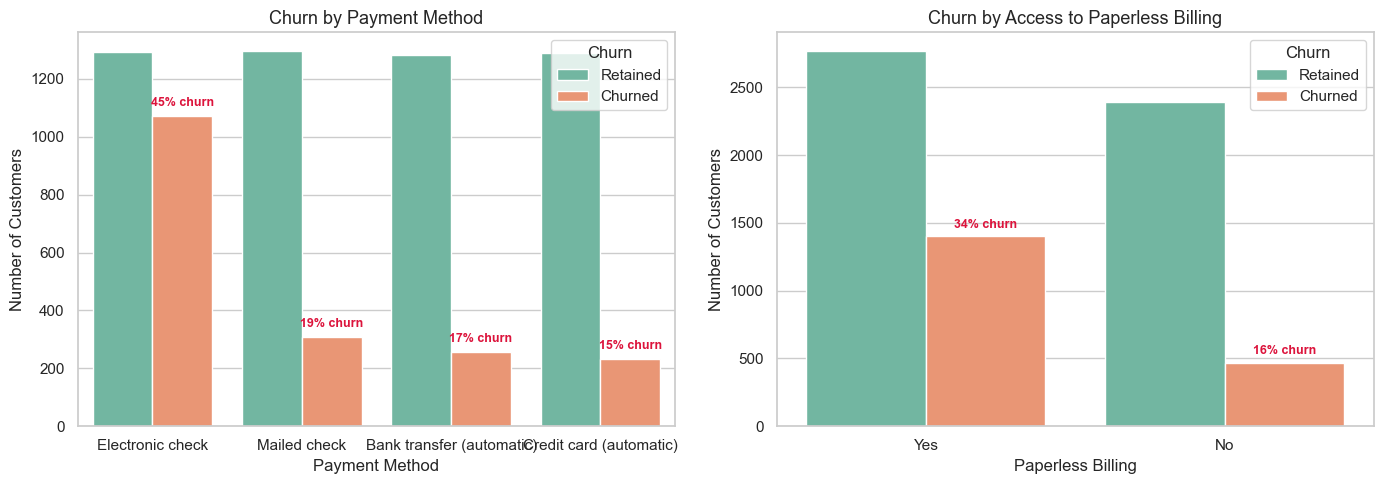

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.countplot(data=df, x="PaymentMethod", hue="Churn", palette=PALETTE, ax=axes[0])
axes[0].set_title("Churn by Payment Method", fontsize=13)
axes[0].set_ylabel("Number of Customers")
axes[0].set_xlabel("Payment Method")
axes[0].legend(title="Churn", labels=["Retained", "Churned"])
add_churn_rate_labels(axes[0], df, "PaymentMethod", fontsize=9)
 
sns.countplot(data=df, x="PaperlessBilling", hue="Churn", palette=PALETTE, ax=axes[1])
axes[1].set_title("Churn by Access to Paperless Billing", fontsize=13)
axes[1].set_ylabel("Number of Customers")
axes[1].set_xlabel("Paperless Billing")
axes[1].legend(title="Churn", labels=["Retained", "Churned"])
add_churn_rate_labels(axes[1], df, "PaperlessBilling", fontsize=9)
 
plt.tight_layout()
plt.savefig("chart5_internet_techsupport.png", dpi=150, bbox_inches="tight")
plt.show()

## CHART SET 6 — Correlation Heatmap (Numerical Features)

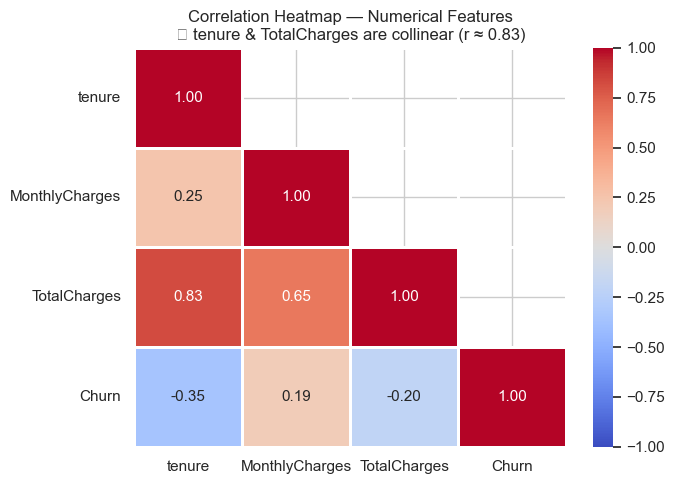

In [79]:
df_heat = df.copy()
df_heat["Churn_num"] = df_heat["Churn"].map({"Yes": 1, "No": 0})
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_num"]
corr_matrix  = df_heat[numeric_cols].corr()
corr_matrix.rename(
    columns={"Churn_num": "Churn"}, index={"Churn_num": "Churn"}, inplace=True
)
 
# Mask the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
 
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, cmap="coolwarm", fmt=".2f",
    linewidths=0.8, vmin=-1, vmax=1,
    annot_kws={"size": 11},
)
plt.title(
    "Correlation Heatmap — Numerical Features\n"
    "⚠ tenure & TotalCharges are collinear (r ≈ 0.83)",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("chart6_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Note: Only 3 numerical features exist in this dataset (tenure, MonthlyCharges,
### TotalCharges).  Churn is encoded as 0/1 to allow inclusion in the matrix.
### The strong tenure–TotalCharges correlation is expected (longer stay = higher
### lifetime spend) and is NOT a useful independent signal.

# SECTION 3 — STATISTICAL TESTING


### Objective: Mathematically validate the patterns observed in EDA so findings can be presented to stakeholders as statistically proven rather than visually suggested.
###
### Two test types are used:
###
###   Chi-Square Test of Independence — for categorical variables vs. Churn.
###     Tests whether the distribution of churn differs significantly across the categories of a given feature. Appropriate when both variables are categorical.
###
###   Mann-Whitney U Test — for numerical variables vs. Churn.
###     A non-parametric test (no normality assumption required) that checks whether churned and non-churned customers differ significantly on a given numeric measure. The choice of Mann-Whitney over a t-test is justified below by a formal skewness check before the tests are run.
###
### Significance threshold: p < 0.05 throughout.

In [80]:
# 3a. Chi-Square Tests — Categorical Variables
 
CATEGORICAL_VARS = [
    "Contract",           # biggest visual signal in the EDA
    "InternetService",    # Fiber Optic paradox
    "TechSupport",        # support-churn link
    "PaymentMethod",      # electronic check users appear elevated
    "PaperlessBilling",   # correlated with digital-first, higher-churn profile
    "OnlineSecurity",     # similar pattern to TechSupport
]
 
print("CHI-SQUARE TESTS — Categorical Variables vs. Churn")
print("-" * 68)
print(f"{'Variable':<22} {'Chi2':>10} {'df':>4} {'p-value':>12}  Result")
 
chi2_results = []
for var in CATEGORICAL_VARS:
    ct = pd.crosstab(df[var], df["Churn"])
    chi2_stat, p_val, dof, _ = chi2_contingency(ct)
    sig    = p_val < ALPHA
    symbol = "✅ Significant" if sig else "❌ Not significant"
    print(f"{var:<22} {chi2_stat:>10.2f} {dof:>4} {p_val:>12.2e}  {symbol}")
    chi2_results.append({
        "Variable": var, "Chi2": chi2_stat,
        "p-value": p_val, "Significant": sig, "Test": "Chi-Square",
    })
 
print()

CHI-SQUARE TESTS — Categorical Variables vs. Churn
--------------------------------------------------------------------
Variable                     Chi2   df      p-value  Result
Contract                  1179.55    2    7.33e-257  ✅ Significant
InternetService            728.70    2    5.83e-159  ✅ Significant
TechSupport                824.93    2    7.41e-180  ✅ Significant
PaymentMethod              645.43    3    1.43e-139  ✅ Significant
PaperlessBilling           256.87    1     8.24e-58  ✅ Significant
OnlineSecurity             846.68    2    1.40e-184  ✅ Significant



In [81]:
# 3b. Skewness Check — Justifying Mann-Whitney Over a t-test

# Skewness interpretation:
#   |skew| < 0.5  → approximately symmetric  → t-test acceptable
#   |skew| 0.5–1  → moderate skew            → Mann-Whitney preferable
#   |skew| > 1    → strong skew              → Mann-Whitney clearly required
# ---------------------------------------------------------------------------
 
NUMERICAL_VARS = ["MonthlyCharges", "tenure", "TotalCharges"]
 
print("SKEWNESS CHECK — Justifying Test Selection for Numerical Variables")
print("=" * 68)
print(f"{'Variable':<22} {'Skewness':>10}  {'Verdict'}")
print("-" * 68)
 
skew_verdicts = {}
for var in NUMERICAL_VARS:
    s = scipy_skew(df[var])
    if abs(s) < 0.5:
        verdict = "~Symmetric  → t-test acceptable"
    elif abs(s) < 1.0:
        verdict = "Moderate skew → Mann-Whitney preferable"
    else:
        verdict = "Strong skew   → Mann-Whitney required"
    print(f"{var:<22} {s:>10.3f}  {verdict}")
    skew_verdicts[var] = s
 
print()

SKEWNESS CHECK — Justifying Test Selection for Numerical Variables
Variable                 Skewness  Verdict
--------------------------------------------------------------------
MonthlyCharges             -0.222  ~Symmetric  → t-test acceptable
tenure                      0.238  ~Symmetric  → t-test acceptable
TotalCharges                0.961  Moderate skew → Mann-Whitney preferable



## CHART SET 7 — Distribution Plots for Numerical Variables

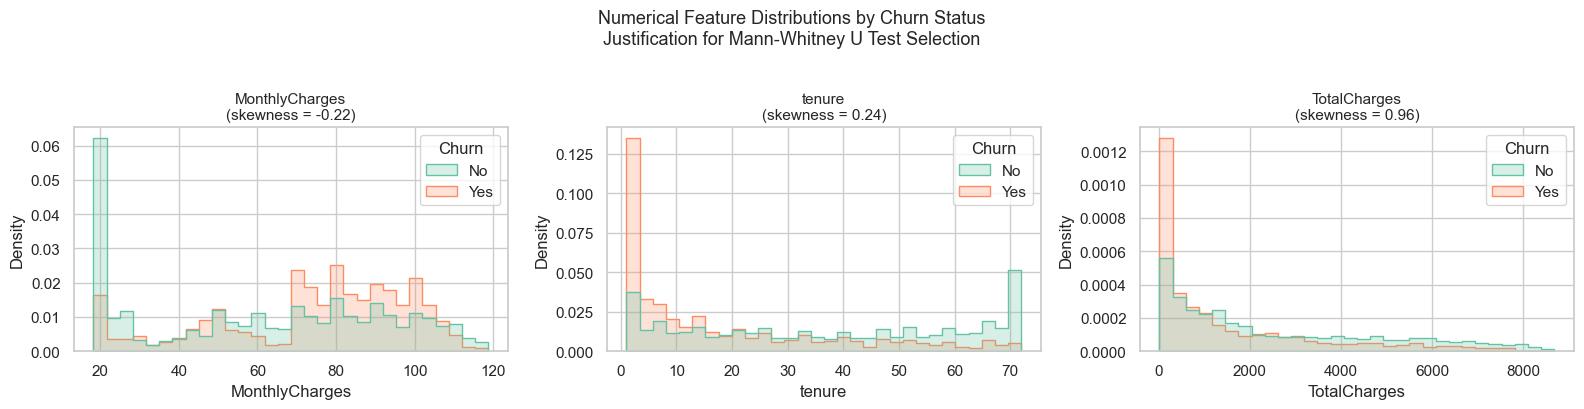

In [82]:
# Visual confirmation of the skewness values above. Each panel shows the
# full distribution split by churn status so the shape — and the difference
# between groups is immediately visible.
# ---------------------------------------------------------------------------
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
for ax, var in zip(axes, NUMERICAL_VARS):
    sns.histplot(
        data=df, x=var, hue="Churn",
        bins=30, palette=PALETTE, element="step",
        stat="density", common_norm=False, ax=ax,
    )
    skew_val = skew_verdicts[var]
    ax.set_title(f"{var}\n(skewness = {skew_val:.2f})", fontsize=11)
    ax.set_ylabel("Density")
 
plt.suptitle(
    "Numerical Feature Distributions by Churn Status\n"
    "Justification for Mann-Whitney U Test Selection",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig("chart7_distribution_skewness.png", dpi=150, bbox_inches="tight")
plt.show()

In [83]:
# 3c. Mann-Whitney U Tests — Numerical Variables
# ---------------------------------------------------------------------------
 
print("=" * 68)
print("MANN-WHITNEY U TESTS — Numerical Variables vs. Churn")
print("=" * 68)
print(f"{'Variable':<22} {'U-Statistic':>14} {'p-value':>12}  Result")
print("-" * 68)
 
mw_results  = []
churn_yes   = df[df["Churn"] == "Yes"]
churn_no    = df[df["Churn"] == "No"]
 
for var in NUMERICAL_VARS:
    u_stat, p_val = mannwhitneyu(
        churn_yes[var], churn_no[var], alternative="two-sided"
    )
    sig    = p_val < ALPHA
    symbol = "✅ Significant" if sig else "❌ Not significant"
    print(f"{var:<22} {u_stat:>14.0f} {p_val:>12.2e}  {symbol}")
    mw_results.append({
        "Variable": var, "U-Stat": u_stat,
        "p-value": p_val, "Significant": sig, "Test": "Mann-Whitney U",
    })
 
print()

MANN-WHITNEY U TESTS — Numerical Variables vs. Churn
Variable                  U-Statistic      p-value  Result
--------------------------------------------------------------------
MonthlyCharges                5986148     8.47e-54  ✅ Significant
tenure                        2494979    6.04e-211  ✅ Significant
TotalCharges                  3360665     2.00e-84  ✅ Significant



## CHART SET 8 — Statistical Significance Summary

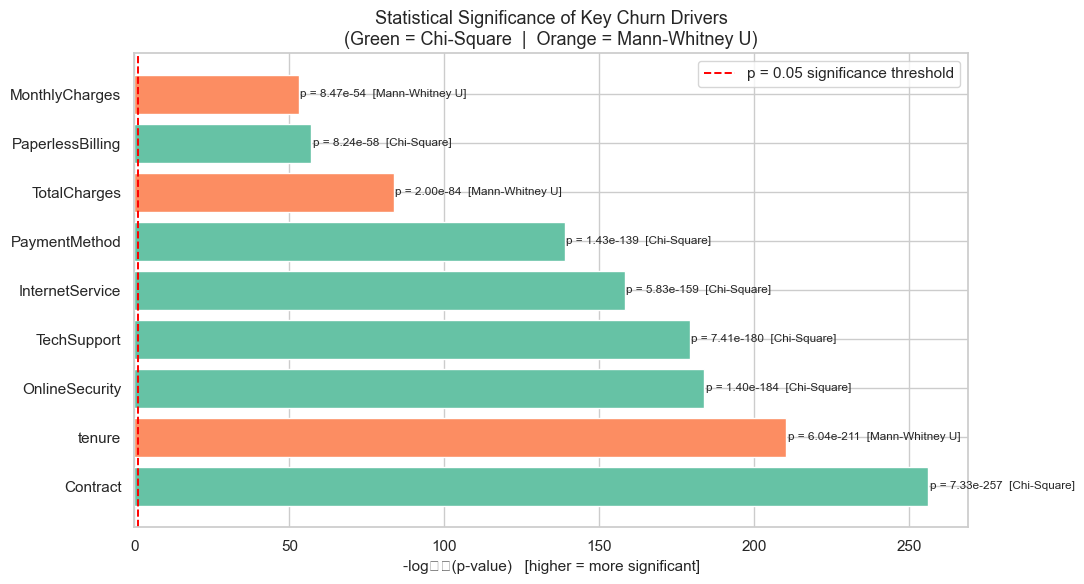

In [84]:
# All tested variables ranked by -log10(p-value). The dashed red line marks
# the p=0.05 threshold. Bars to the right are statistically significant.
# ---------------------------------------------------------------------------
 
all_stats = []
for r in chi2_results + mw_results:
    all_stats.append({
        "Variable": r["Variable"],
        "p-value":  r["p-value"],
        "Test":     r["Test"],
    })
 
stats_df = pd.DataFrame(all_stats).sort_values("p-value")
bar_colors = [
    sns.color_palette(PALETTE)[0] if r["Test"] == "Chi-Square"
    else sns.color_palette(PALETTE)[1]
    for _, r in stats_df.iterrows()
]
 
plt.figure(figsize=(11, 6))
bars = plt.barh(
    stats_df["Variable"],
    -np.log10(stats_df["p-value"]),
    color=bar_colors,
)
plt.axvline(
    -np.log10(ALPHA), color="red", linestyle="--",
    linewidth=1.4, label=f"p = {ALPHA} significance threshold",
)
plt.xlabel("-log₁₀(p-value)   [higher = more significant]", fontsize=11)
plt.title(
    "Statistical Significance of Key Churn Drivers\n"
    "(Green = Chi-Square  |  Orange = Mann-Whitney U)",
    fontsize=13,
)
plt.legend()
 
for bar, (_, row) in zip(bars, stats_df.iterrows()):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"p = {row['p-value']:.2e}  [{row['Test']}]",
        va="center", fontsize=8.5,
    )
 
plt.tight_layout()
plt.savefig("chart8_statistical_significance.png", dpi=150, bbox_inches="tight")
plt.show()

# SECTION 4 — PREDICTIVE MODELLING: MULTI-MODEL COMPARISON

### Four models are trained on identical train/test splits and compared on metrics that matter for an imbalanced churn classification problem:
#
###   Recall (Churn class)  — PRIMARY metric: catching real churners.
###                           A missed churner = lost revenue with no intervention.
###   Precision (Churn)     — avoiding wasted retention spend on false alarms.
###   F1 (Churn)            — harmonic mean; balances recall and precision.
###   ROC-AUC               — overall discriminative power across all thresholds.
###   Accuracy              — included for reference; unreliable on imbalanced data.
###
### Why not accuracy alone?
###   A model predicting "No Churn" for every customer achieves ~74% accuracy
###   while being completely useless. Recall for the Churn class is the metric
###   the retention team actually needs to optimise.
#
### Class imbalance handling:
###   class_weight="balanced" is applied to all models that support it.
###   Gradient Boosting does not support this parameter directly, so the
###   subsample and learning rate are tuned conservatively instead.


In [85]:
# 4a. Data Preparation 
# ----------------------------------------------------
 
df_ml = pd.get_dummies(df, drop_first=True)
 
target_col = "Churn_Yes"
if target_col not in df_ml.columns:
    raise KeyError(
        f"Expected target column '{target_col}' not found after encoding. "
        f"Available columns: {list(df_ml.columns)}"
    )
 
X = df_ml.drop(columns=[target_col])
y = df_ml[target_col]
 
print(f"\nFeatures : {X.shape[1]}")
print(f"Samples  : {X.shape[0]}  "
      f"({y.sum()} churners / {(~y.astype(bool)).sum()} non-churners  |  "
      f"{y.mean()*100:.1f}% churn rate)\n")
 
# Stratified split — preserves the ~26/74 class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)


Features : 30
Samples  : 7032  (1869 churners / 5163 non-churners  |  26.6% churn rate)



In [86]:
# 4b. Model Definitions 
# ---------------------------------------------------
# Logistic Regression is wrapped in a Pipeline with StandardScaler because
# it is sensitive to feature magnitude. Tree-based models do not require scaling.
 
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_SEED,
        )),
    ]),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=8,            # capped to prevent overfitting on training data
        random_state=RANDOM_SEED,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,              # use all available CPU cores
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,     # lower LR = more conservative, less overfitting
        max_depth=4,
        subsample=0.8,          # stochastic boosting helps with imbalanced data
        random_state=RANDOM_SEED,
    ),
}

In [87]:
# 4c. Train, Predict & Collect Metrics 
# --------------------------------------------
 
results   = []
all_preds = {}
 
print(f"{'Model':<25} {'Accuracy':>9} {'Recall':>8} {'Precision':>10} {'F1':>7} {'ROC-AUC':>9}")
print("-" * 72)
 
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
 
    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
 
    print(f"{name:<25} {acc:>9.3f} {rec:>8.3f} {prec:>10.3f} {f1:>7.3f} {auc:>9.3f}")
    results.append({
        "Model": name, "Accuracy": acc, "Recall": rec,
        "Precision": prec, "F1": f1, "ROC-AUC": auc,
    })
    all_preds[name] = (y_pred, y_proba)
 
print()
results_df = pd.DataFrame(results).set_index("Model")
 
# Best model by Recall (primary), then F1 as tiebreaker
best_model_name = results_df.sort_values(
    ["Recall", "F1"], ascending=False
).index[0]
print(f"🏆 Best model by Recall + F1 : {best_model_name}\n")

Model                      Accuracy   Recall  Precision      F1   ROC-AUC
------------------------------------------------------------------------
Logistic Regression           0.748    0.789      0.518   0.625     0.835
Decision Tree                 0.740    0.733      0.507   0.600     0.804
Random Forest                 0.780    0.463      0.613   0.527     0.828
Gradient Boosting             0.788    0.497      0.628   0.555     0.836

🏆 Best model by Recall + F1 : Logistic Regression



## CHART SET 9 — Model Comparison Bar Chart

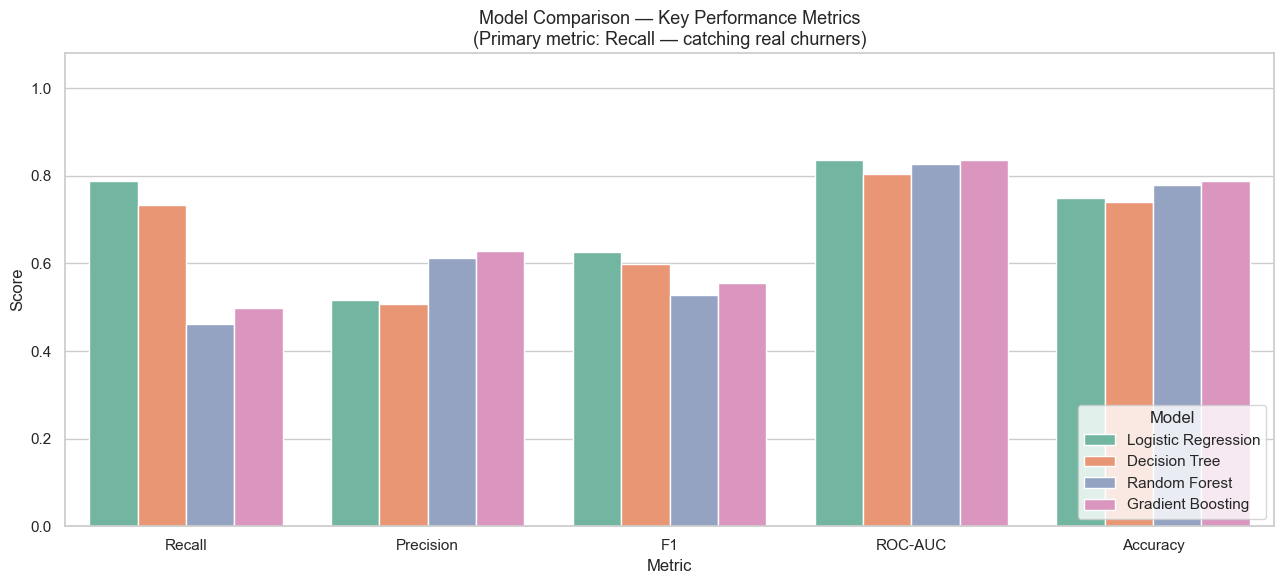

In [88]:
metrics_to_plot = ["Recall", "Precision", "F1", "ROC-AUC", "Accuracy"]
plot_df = (
    results_df[metrics_to_plot]
    .reset_index()
    .melt(id_vars="Model", var_name="Metric", value_name="Score")
)
 
plt.figure(figsize=(13, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette=PALETTE)
plt.title(
    "Model Comparison — Key Performance Metrics\n"
    "(Primary metric: Recall — catching real churners)",
    fontsize=13,
)
plt.ylabel("Score")
plt.ylim(0, 1.08)
plt.legend(loc="lower right", title="Model")
plt.tight_layout()
plt.savefig("chart9_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## CHART SET 10 — Confusion Matrices (all 4 models)

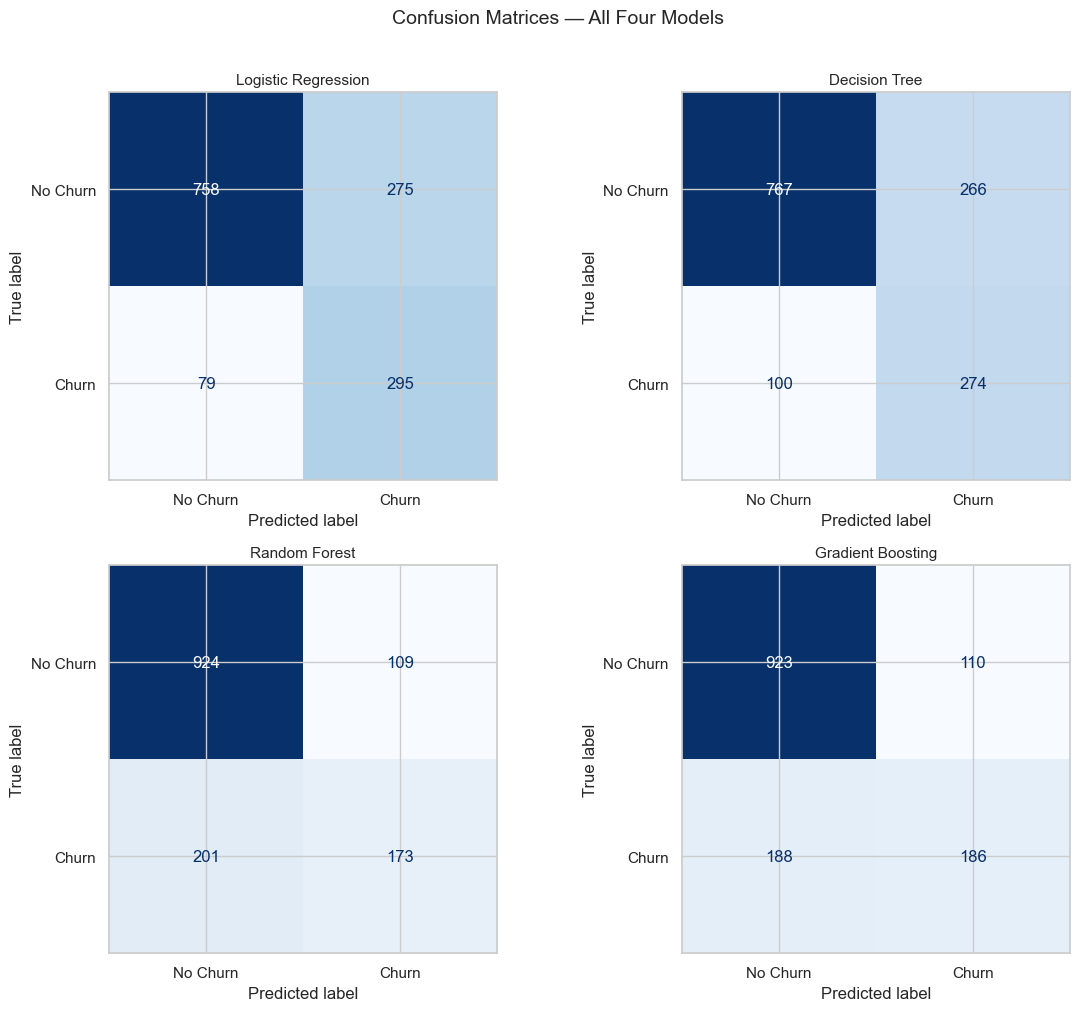

In [89]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes_flat = axes.flatten()
 
for ax, (name, (y_pred, _)) in zip(axes_flat, all_preds.items()):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["No Churn", "Churn"]
    )
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name}", fontsize=11)
 
plt.suptitle("Confusion Matrices — All Four Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("chart10_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## CHART SET 11 — Feature Importance ((Random Forest))

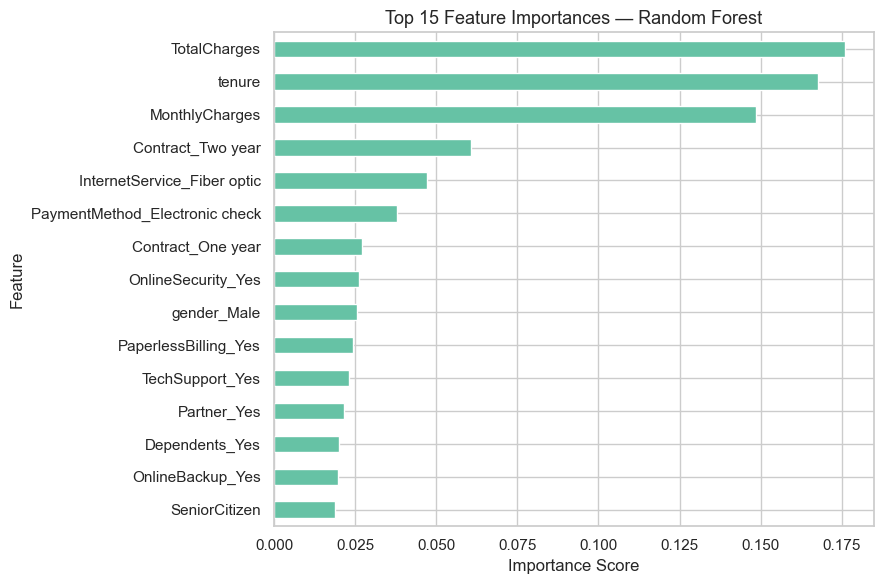

In [90]:
rf_model    = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15       = importances.nlargest(15).sort_values()
 
plt.figure(figsize=(9, 6))
top15.plot(kind="barh", color=sns.color_palette(PALETTE)[0])
plt.title("Top 15 Feature Importances — Random Forest", fontsize=13)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("chart11_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [91]:
# 4d. Detailed Classification Report — Best Model
# ---------------------------------------------------------------
 
print(f"DETAILED CLASSIFICATION REPORT — {best_model_name}")
print("-" * 68)
best_pred, _ = all_preds[best_model_name]
print(classification_report(y_test, best_pred, target_names=["No Churn", "Churn"]))
 
print("\n✅ Analysis complete. All 9 charts saved to working directory.")

DETAILED CLASSIFICATION REPORT — Logistic Regression
--------------------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1033
       Churn       0.52      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407


✅ Analysis complete. All 9 charts saved to working directory.


# SECTION 5 — Analytics

In [92]:
best_model  = models[best_model_name]
churn_proba = best_model.predict_proba(X)[:, 1]
 
df["Churn_Flag"] = (df["Churn"] == "Yes").astype(int)
df["churn_prob"] = churn_proba
 
COLORS = sns.color_palette(PALETTE)
print(f"\nScores computed using: {best_model_name}")
print(f"Customers scored: {len(df):,}")


Scores computed using: Logistic Regression
Customers scored: 7,032


## A: Cohort Analysis

In [93]:
# Section A — Cohort Analysis
 
# A cohort groups customers who "joined" in the same period. Because this
# dataset has no calendar dates, we use **tenure bands** as a proxy for
# joining time. This reveals whether newer customers are higher risk, whether
# pricing has shifted over time, and whether the contract mix explains the
# churn differences between cohorts
 
# Assign cohorts based on tenure
cohort_bins   = [0, 12, 24, 48, 72]
cohort_labels = ["0–12 mo (new)", "13–24 mo (early)",
                 "25–48 mo (mid)", "49–72 mo (mature)"]
 
df["Cohort"] = pd.cut(
    df["tenure"], bins=cohort_bins,
    labels=cohort_labels, right=True, include_lowest=True,
)
 
# Cohort-level summary metrics
cohort_summary = (
    df.groupby("Cohort", observed=True)
    .agg(
        n_customers   = ("Churn_Flag", "count"),
        churn_rate    = ("Churn_Flag", "mean"),
        avg_monthly   = ("MonthlyCharges", "mean"),
        avg_total_clv = ("TotalCharges", "mean"),
    )
    .reset_index()
)
cohort_summary["churn_rate_pct"] = cohort_summary["churn_rate"] * 100
 
print("Cohort Summary:")
print(cohort_summary[["Cohort","n_customers","churn_rate_pct",
                        "avg_monthly","avg_total_clv"]].to_string(index=False))
 
# Contract mix per cohort
cohort_contract = (
    df.groupby(["Cohort","Contract"], observed=True)
    .size().reset_index(name="count")
)
cohort_contract["pct"] = (
    cohort_contract.groupby("Cohort", observed=True)["count"]
    .transform(lambda x: x / x.sum() * 100)
)

Cohort Summary:
           Cohort  n_customers  churn_rate_pct  avg_monthly  avg_total_clv
    0–12 mo (new)         2175       47.678161    56.172023     276.621563
 13–24 mo (early)         1024       28.710938    61.357275    1126.257520
   25–48 mo (mid)         1594       20.388959    65.930552    2390.451913
49–72 mo (mature)         2239        9.513176    73.945377    4685.506364


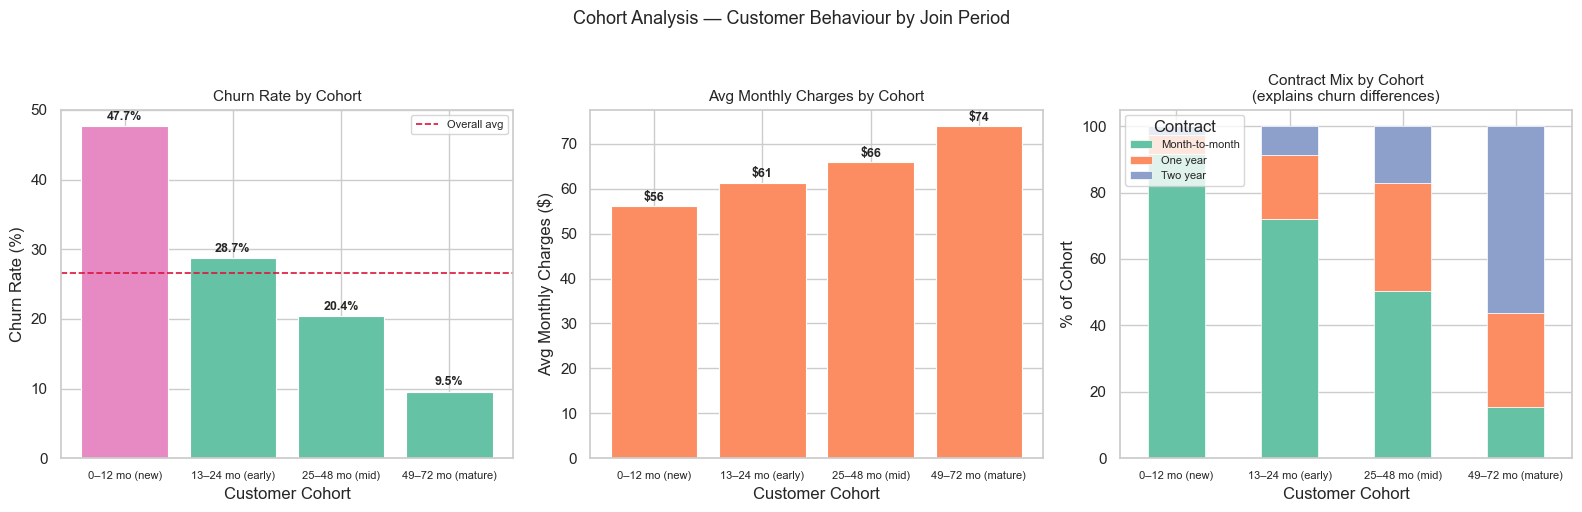

In [94]:
# Chart A1 — three panels: churn rate, avg charges, contract mix
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
bars = axes[0].bar(
    cohort_summary["Cohort"], cohort_summary["churn_rate_pct"],
    color=[COLORS[3] if r > 30 else COLORS[0]
           for r in cohort_summary["churn_rate_pct"]],
    edgecolor="white", linewidth=0.8,
)
axes[0].axhline(df["Churn_Flag"].mean() * 100, color="crimson",
                linestyle="--", linewidth=1.2, label="Overall avg")
for bar, val in zip(bars, cohort_summary["churn_rate_pct"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold")
axes[0].set_title("Churn Rate by Cohort", fontsize=11)
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_xlabel("Customer Cohort")
axes[0].tick_params(axis="x", labelsize=8)
axes[0].legend(fontsize=8)
 
axes[1].bar(cohort_summary["Cohort"], cohort_summary["avg_monthly"],
            color=COLORS[1], edgecolor="white", linewidth=0.8)
for i, (_, row) in enumerate(cohort_summary.iterrows()):
    axes[1].text(i, row["avg_monthly"] + 0.5, f"${row['avg_monthly']:.0f}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_title("Avg Monthly Charges by Cohort", fontsize=11)
axes[1].set_ylabel("Avg Monthly Charges ($)")
axes[1].set_xlabel("Customer Cohort")
axes[1].tick_params(axis="x", labelsize=8)
 
contract_pivot = cohort_contract.pivot(
    index="Cohort", columns="Contract", values="pct"
).fillna(0)
contract_pivot.plot(kind="bar", stacked=True, ax=axes[2],
                    color=COLORS[:3], edgecolor="white", linewidth=0.5)
axes[2].set_title("Contract Mix by Cohort\n(explains churn differences)", fontsize=11)
axes[2].set_ylabel("% of Cohort")
axes[2].set_xlabel("Customer Cohort")
axes[2].tick_params(axis="x", rotation=0, labelsize=8)
axes[2].legend(title="Contract", fontsize=8, loc="upper left")
 
plt.suptitle("Cohort Analysis — Customer Behaviour by Join Period",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("adv_A1_cohort_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

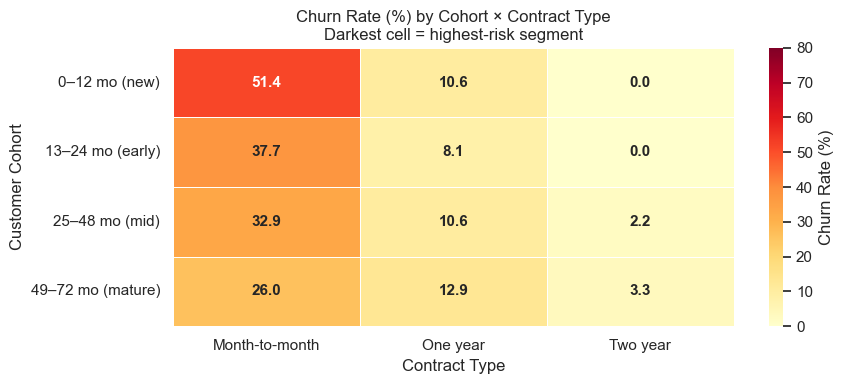

In [95]:
# Chart A2 — cohort × contract churn heatmap
pivot = (
    df.groupby(["Cohort","Contract"], observed=True)["Churn_Flag"]
    .mean().mul(100).reset_index()
    .pivot(index="Cohort", columns="Contract", values="Churn_Flag")
)
 
plt.figure(figsize=(9, 4))
sns.heatmap(
    pivot, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, vmin=0, vmax=80,
    annot_kws={"size": 11, "weight": "bold"},
    cbar_kws={"label": "Churn Rate (%)"},
)
plt.title("Churn Rate (%) by Cohort × Contract Type\n"
          "Darkest cell = highest-risk segment", fontsize=12)
plt.ylabel("Customer Cohort")
plt.xlabel("Contract Type")
plt.tight_layout()
plt.savefig("adv_A2_cohort_contract_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## B: Retention Curves

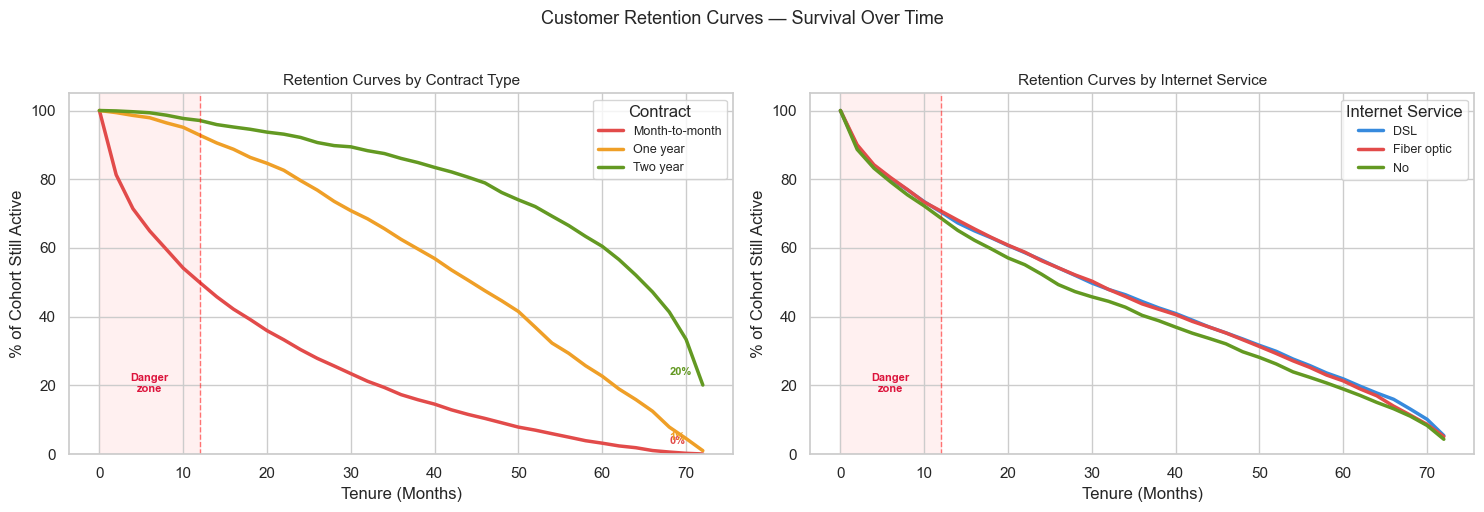

Retention at 12-month mark:
  Month-to-month        : 49.9% still active
  One year              : 92.8% still active
  Two year              : 97.1% still active


In [109]:
# At each month **t**, we compute what fraction of a starting cohort is still
# active. A customer is "still active at t" if they haven't churned yet:
# - Churn = No  →  still active at every month up to their current tenure
# - Churn = Yes →  still active up to month tenure-1, then gone
 
# We plot this separately for **contract type** and **internet service** to
# show how the commitment level and service tier change the retention shape.

 
def compute_retention(subset):
    baseline = len(subset)
    months, retention = [], []
    for t in range(0, int(subset["tenure"].max()) + 1, 2):
        still_active = (
            ((subset["Churn"] == "No")  & (subset["tenure"] >= t)) |
            ((subset["Churn"] == "Yes") & (subset["tenure"] >  t))
        ).sum()
        months.append(t)
        retention.append(still_active / baseline * 100)
    return pd.DataFrame({"month": months, "pct": retention})

contract_ret = {c: compute_retention(df[df["Contract"] == c]) for c in df["Contract"].unique()}
internet_ret = {s: compute_retention(df[df["InternetService"] == s]) for s in df["InternetService"].unique()}
 
contract_colors = {
    "Month-to-month": "#E24B4A",
    "One year":        "#EF9F27",
    "Two year":        "#639922",
}
internet_colors = {
    "Fiber optic": "#E24B4A",
    "DSL":          "#378ADD",
    "No":           "#639922",
}
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
for contract in df["Contract"].unique():
    ret = compute_retention(df[df["Contract"] == contract])
    axes[0].plot(ret["month"], ret["pct"],
                 label=contract,
                 color=contract_colors.get(contract, COLORS[0]),
                 linewidth=2.5)
    axes[0].annotate(
        f"{ret['pct'].iloc[-1]:.0f}%",
        xy=(ret["month"].iloc[-1], ret["pct"].iloc[-1]),
        xytext=(ret["month"].iloc[-1] - 4, ret["pct"].iloc[-1] + 3),
        fontsize=8, fontweight="bold",
        color=contract_colors.get(contract, "black"),
    )
 
for service in df["InternetService"].unique():
    ret = compute_retention(df[df["InternetService"] == service])
    axes[1].plot(ret["month"], ret["pct"],
                 label=service,
                 color=internet_colors.get(service, COLORS[0]),
                 linewidth=2.5)
 
for ax in axes:
    ax.axvspan(0, 12, alpha=0.06, color="red", zorder=0)
    ax.axvline(12, color="red", linestyle="--", linewidth=1, alpha=0.5)
    ax.text(6, 18, "Danger\nzone", ha="center", fontsize=8,
            color="crimson", fontweight="bold")
    ax.set_xlabel("Tenure (Months)")
    ax.set_ylabel("% of Cohort Still Active")
    ax.set_ylim(0, 105)
 
axes[0].set_title("Retention Curves by Contract Type", fontsize=11)
axes[0].legend(title="Contract", fontsize=9)
axes[1].set_title("Retention Curves by Internet Service", fontsize=11)
axes[1].legend(title="Internet Service", fontsize=9)
 
plt.suptitle("Customer Retention Curves — Survival Over Time",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("adv_B1_retention_curves.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("Retention at 12-month mark:")
for contract in df["Contract"].unique():
    ret = compute_retention(df[df["Contract"] == contract])
    r12 = ret[ret["month"] <= 12].iloc[-1]["pct"]
    print(f"  {contract:<22}: {r12:.1f}% still active")


## C: CLV Risk Segmentation

In [97]:
### 💰 Section C — Customer Lifetime Value Risk Segmentation
 
# We compute two CLV components for every customer:
# - **Realised CLV** = TotalCharges (what they have already paid)
# - **Projected CLV** = MonthlyCharges × estimated remaining tenure
 
# Remaining tenure is estimated as the median tenure of *retained* customers
# in the same contract group minus the customer's current tenure. This is
# conservative and anchored to real observed behaviour.
 
# Customers are then placed into a **2×2 matrix**:
 
# |                | Low Churn Risk | High Churn Risk |
# |----------------|---------------|-----------------|
# | **High CLV**   | STABLE        | **CRITICAL** 🚨 |
# | **Low CLV**    | HEALTHY       | MONITOR         |
 
# The **CRITICAL** quadrant is the primary output — high-value customers the
# model predicts will leave. Every customer here has a revenue figure attached,
# making the business case for retention spend concrete.
 
df_clv = df.copy()
 
df_clv["CLV_Realised"] = df_clv["TotalCharges"]
 
median_retained = (
    df_clv[df_clv["Churn"] == "No"]
    .groupby("Contract")["tenure"]
    .median()
    .rename("median_retained_tenure")
)
df_clv = df_clv.join(median_retained, on="Contract")
df_clv["remaining_tenure"] = (
    df_clv["median_retained_tenure"] - df_clv["tenure"]
).clip(lower=0)
df_clv["CLV_Projected"] = df_clv["MonthlyCharges"] * df_clv["remaining_tenure"]
df_clv["CLV_Total"]     = df_clv["CLV_Realised"] + df_clv["CLV_Projected"]
 
clv_threshold  = df_clv["CLV_Total"].median()
risk_threshold = 0.50
 
segment_colors = {
    "CRITICAL": "#E24B4A",
    "STABLE":   "#378ADD",
    "MONITOR":  "#EF9F27",
    "HEALTHY":  "#639922",
}
 
def label_segment(row):
    high_clv  = row["CLV_Total"]  >= clv_threshold
    high_risk = row["churn_prob"] >= risk_threshold
    if   high_clv  and     high_risk: return "CRITICAL"
    elif high_clv  and not high_risk: return "STABLE"
    elif not high_clv and  high_risk: return "MONITOR"
    else:                              return "HEALTHY"
 
df_clv["Segment"] = df_clv.apply(label_segment, axis=1)
 
seg_summary = (
    df_clv.groupby("Segment")
    .agg(
        n_customers           = ("Churn_Flag", "count"),
        actual_churn_rate     = ("Churn_Flag", "mean"),
        avg_monthly           = ("MonthlyCharges", "mean"),
        avg_clv               = ("CLV_Total", "mean"),
        total_revenue_at_risk = ("CLV_Total", "sum"),
    )
    .reset_index()
)
seg_summary["actual_churn_rate"] *= 100
seg_summary["pct_of_total"] = seg_summary["n_customers"] / len(df_clv) * 100
 
print("CLV Risk Segment Summary:")
print(seg_summary.to_string(index=False))
 
critical = df_clv[df_clv["Segment"] == "CRITICAL"]
print(f"\n🚨 CRITICAL: {len(critical):,} customers")
print(f"   Revenue at risk : ${critical['CLV_Total'].sum():,.0f}")
print(f"   Avg monthly     : ${critical['MonthlyCharges'].mean():.2f}")
print(f"   Avg churn prob  : {critical['churn_prob'].mean()*100:.1f}%")

CLV Risk Segment Summary:
 Segment  n_customers  actual_churn_rate  avg_monthly     avg_clv  total_revenue_at_risk  pct_of_total
CRITICAL         1043          42.569511    92.918456 3492.527996             3642706.70     14.832196
 HEALTHY         1669           9.766327    26.500659  923.358628             1541085.55     23.734357
 MONITOR         1847          57.065512    67.266405 1092.899404             2018585.20     26.265643
  STABLE         2473           8.410837    76.941529 4620.149131            11425628.80     35.167804

🚨 CRITICAL: 1,043 customers
   Revenue at risk : $3,642,707
   Avg monthly     : $92.92
   Avg churn prob  : 68.9%


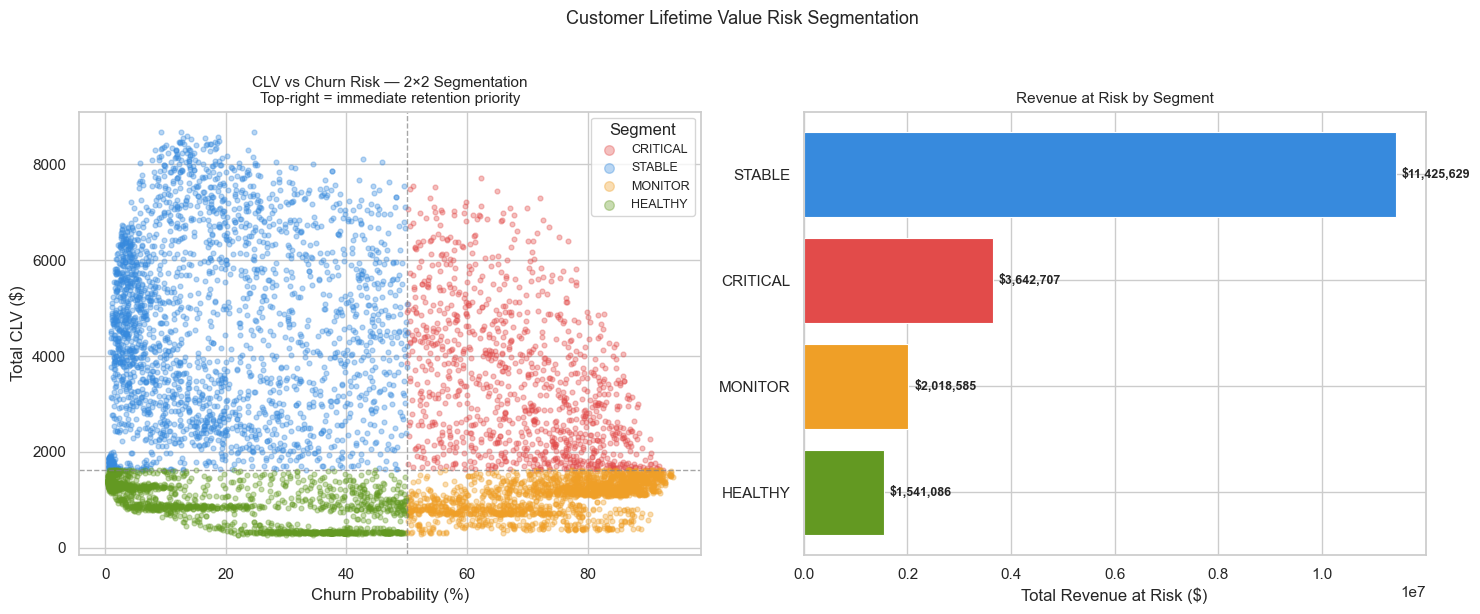

In [98]:
# Chart C1 — 2×2 scatter + revenue at risk bars
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
for seg, color in segment_colors.items():
    mask = df_clv["Segment"] == seg
    axes[0].scatter(
        df_clv.loc[mask, "churn_prob"] * 100,
        df_clv.loc[mask, "CLV_Total"],
        c=color, alpha=0.35, s=12, label=seg, rasterized=True,
    )
axes[0].axvline(risk_threshold * 100, color="grey",
                linestyle="--", linewidth=1, alpha=0.7)
axes[0].axhline(clv_threshold, color="grey",
                linestyle="--", linewidth=1, alpha=0.7)
axes[0].set_xlabel("Churn Probability (%)")
axes[0].set_ylabel("Total CLV ($)")
axes[0].set_title("CLV vs Churn Risk — 2×2 Segmentation\n"
                  "Top-right = immediate retention priority", fontsize=11)
axes[0].legend(title="Segment", fontsize=9, markerscale=2)
 
rev = seg_summary.sort_values("total_revenue_at_risk", ascending=True)
bars = axes[1].barh(
    rev["Segment"], rev["total_revenue_at_risk"],
    color=[segment_colors[s] for s in rev["Segment"]],
    edgecolor="white", linewidth=0.8,
)
for bar, val in zip(bars, rev["total_revenue_at_risk"]):
    axes[1].text(
        bar.get_width() + rev["total_revenue_at_risk"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}", va="center", fontsize=9, fontweight="bold",
    )
axes[1].set_xlabel("Total Revenue at Risk ($)")
axes[1].set_title("Revenue at Risk by Segment", fontsize=11)
 
plt.suptitle("Customer Lifetime Value Risk Segmentation",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("adv_C1_clv_risk_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

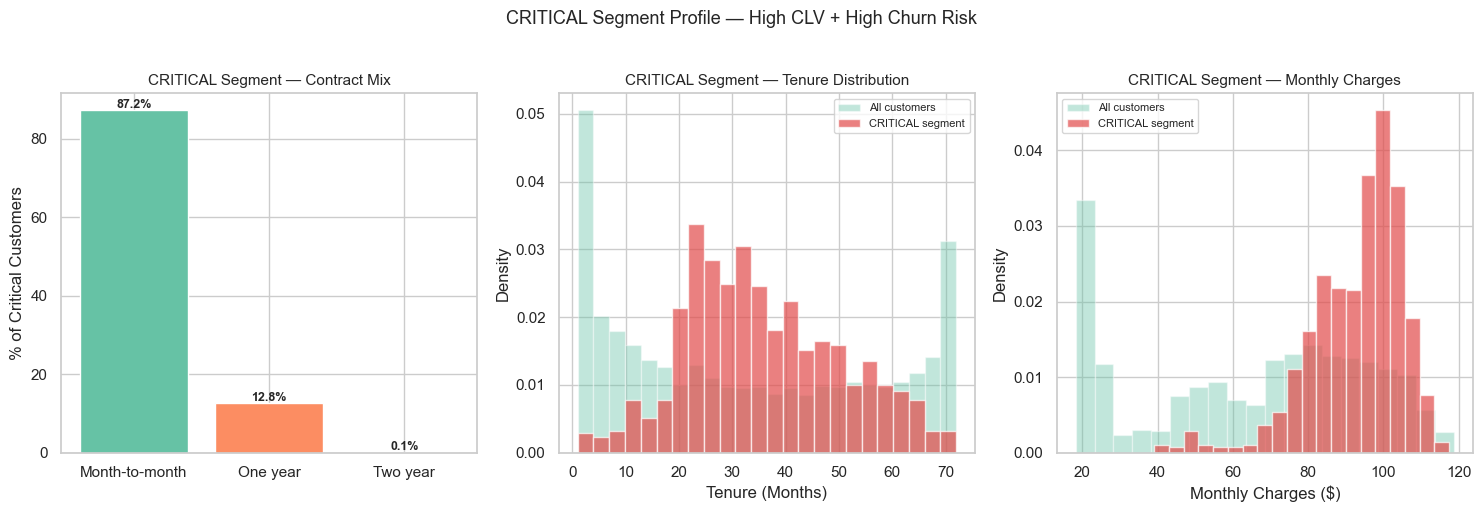

In [99]:
# Chart C2 — CRITICAL segment profile
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
cc = critical["Contract"].value_counts(normalize=True) * 100
axes[0].bar(cc.index, cc.values, color=COLORS[:len(cc)], edgecolor="white")
for i, v in enumerate(cc.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center",
                 fontsize=9, fontweight="bold")
axes[0].set_title("CRITICAL Segment — Contract Mix", fontsize=11)
axes[0].set_ylabel("% of Critical Customers")
 
axes[1].hist(df_clv["tenure"], bins=24, alpha=0.4, color=COLORS[0],
             label="All customers", density=True)
axes[1].hist(critical["tenure"], bins=24, alpha=0.7, color="#E24B4A",
             label="CRITICAL segment", density=True)
axes[1].set_title("CRITICAL Segment — Tenure Distribution", fontsize=11)
axes[1].set_xlabel("Tenure (Months)")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)
 
axes[2].hist(df_clv["MonthlyCharges"], bins=20, alpha=0.4, color=COLORS[0],
             label="All customers", density=True)
axes[2].hist(critical["MonthlyCharges"], bins=20, alpha=0.7, color="#E24B4A",
             label="CRITICAL segment", density=True)
axes[2].set_title("CRITICAL Segment — Monthly Charges", fontsize=11)
axes[2].set_xlabel("Monthly Charges ($)")
axes[2].set_ylabel("Density")
axes[2].legend(fontsize=8)
 
plt.suptitle("CRITICAL Segment Profile — High CLV + High Churn Risk",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("adv_C2_critical_segment_profile.png", dpi=150, bbox_inches="tight")
plt.show

## D: Survival Analysis (Kaplan-Meier)

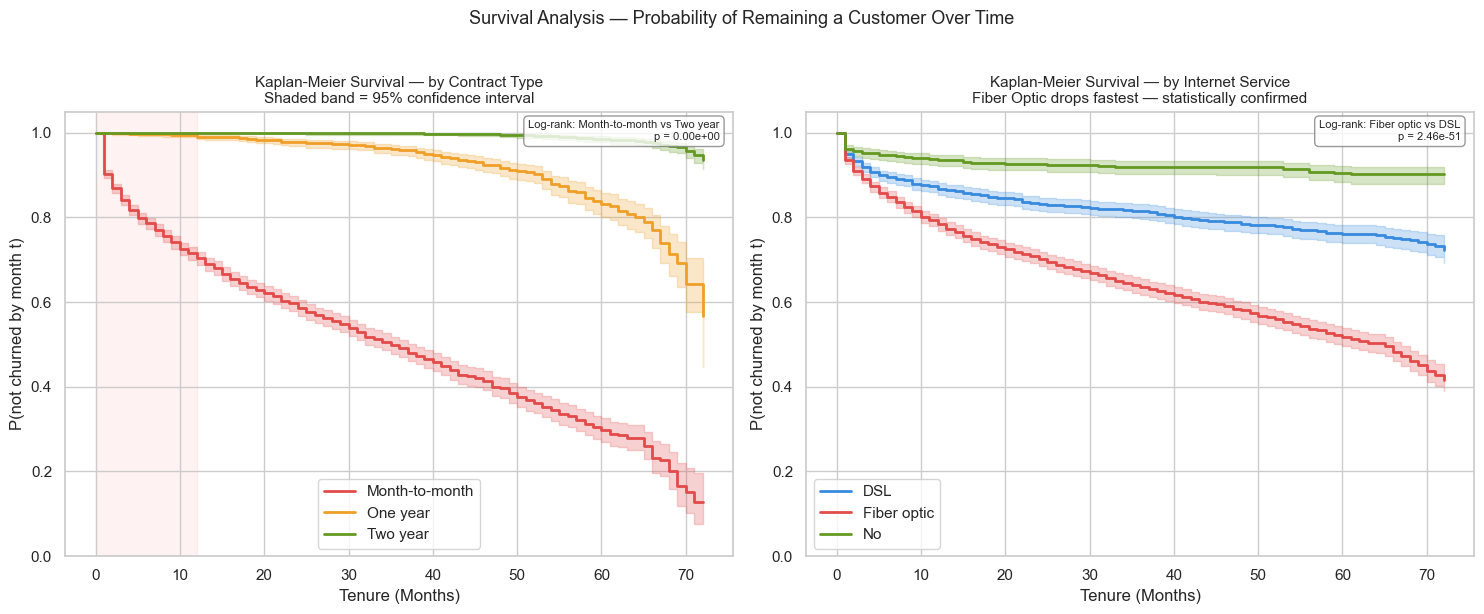

Median survival time by contract:
  Month-to-month        : 35 months
  One year              : > 72 months (median not reached)
  Two year              : > 72 months (median not reached)


In [100]:
### 📊 Section D — Survival Analysis (Kaplan-Meier)
 
# The Kaplan-Meier estimator answers: **"What is the probability a customer
# still active at month t?"**
 
# The key advantage over a simple retention curve is that KM correctly handles
# **right-censoring** — customers who haven't churned yet. We know they survived
# *at least* to their current tenure, but not whether they will eventually
# churn. Ignoring these customers would underestimate how long customers
# actually stay. KM incorporates them as censored observations.
 
# The **log-rank test** confirms whether the survival curves of different
# groups are statistically different — annotated directly on each chart.
 
if LIFELINES_AVAILABLE:
    kmf = KaplanMeierFitter()
 
    contract_colors = {
        "Month-to-month": "#E24B4A",
        "One year":        "#EF9F27",
        "Two year":        "#639922",
    }
    internet_colors = {
        "Fiber optic": "#E24B4A",
        "DSL":          "#378ADD",
        "No":           "#639922",
    }
 
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
    for contract in df["Contract"].unique():
        mask = df["Contract"] == contract
        kmf.fit(
            durations      = df.loc[mask, "tenure"],
            event_observed = df.loc[mask, "Churn_Flag"],
            label          = contract,
        )
        kmf.plot_survival_function(
            ax=axes[0], ci_show=True,
            color=contract_colors.get(contract, "grey"),
            linewidth=2.0,
        )
 
    mtm = df[df["Contract"] == "Month-to-month"]
    ty  = df[df["Contract"] == "Two year"]
    lr  = logrank_test(mtm["tenure"], ty["tenure"],
                       event_observed_A=mtm["Churn_Flag"],
                       event_observed_B=ty["Churn_Flag"])
    axes[0].text(
        0.98, 0.98,
        f"Log-rank: Month-to-month vs Two year\np = {lr.p_value:.2e}",
        transform=axes[0].transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="grey", alpha=0.8),
    )
    axes[0].axvspan(0, 12, alpha=0.05, color="red", zorder=0)
    axes[0].set_title("Kaplan-Meier Survival — by Contract Type\n"
                      "Shaded band = 95% confidence interval", fontsize=11)
    axes[0].set_xlabel("Tenure (Months)")
    axes[0].set_ylabel("P(not churned by month t)")
    axes[0].set_ylim(0, 1.05)
 
    for service in df["InternetService"].unique():
        mask = df["InternetService"] == service
        kmf.fit(
            durations      = df.loc[mask, "tenure"],
            event_observed = df.loc[mask, "Churn_Flag"],
            label          = service,
        )
        kmf.plot_survival_function(
            ax=axes[1], ci_show=True,
            color=internet_colors.get(service, "grey"),
            linewidth=2.0,
        )
 
    fiber = df[df["InternetService"] == "Fiber optic"]
    dsl   = df[df["InternetService"] == "DSL"]
    lr2   = logrank_test(fiber["tenure"], dsl["tenure"],
                         event_observed_A=fiber["Churn_Flag"],
                         event_observed_B=dsl["Churn_Flag"])
    axes[1].text(
        0.98, 0.98,
        f"Log-rank: Fiber optic vs DSL\np = {lr2.p_value:.2e}",
        transform=axes[1].transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="grey", alpha=0.8),
    )
    axes[1].set_title("Kaplan-Meier Survival — by Internet Service\n"
                      "Fiber Optic drops fastest — statistically confirmed",
                      fontsize=11)
    axes[1].set_xlabel("Tenure (Months)")
    axes[1].set_ylabel("P(not churned by month t)")
    axes[1].set_ylim(0, 1.05)
 
    plt.suptitle("Survival Analysis — Probability of Remaining a Customer Over Time",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("adv_D1_survival_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
 
    print("Median survival time by contract:")
    for contract in df["Contract"].unique():
        mask = df["Contract"] == contract
        kmf.fit(df.loc[mask, "tenure"], df.loc[mask, "Churn_Flag"], label=contract)
        t = kmf.median_survival_time_
        print(f"  {contract:<22}: "
              + (f"{t:.0f} months"
                 if not np.isinf(t)
                 else f"> {df['tenure'].max()} months (median not reached)"))
 
else:
    print("Section D skipped. Run:  pip install lifelines")

## E: Churn Risk Scoring & Segmentation

In [101]:
### 🎯 Section E — Churn Risk Scoring & Segmentation
 
# Every customer is assigned a **churn probability score** (0–1) from the
# best-performing model and bucketed into four actionable risk tiers:
 
# | Tier     | Score threshold | Action                              |
# |----------|----------------|--------------------------------------|
# | CRITICAL | ≥ 0.75         | Immediate personal outreach          |
# | HIGH     | ≥ 0.50         | Automated offer within 48 hours      |
# | MEDIUM   | ≥ 0.25         | Soft-touch nurture campaign           |
# | LOW      | < 0.25         | No action needed                     |
 
# The **tier validation chart** (actual churn rate per tier) is the most
# important output — it confirms the model is well-calibrated. A properly
# calibrated model produces monotonically increasing actual churn rates
# from LOW → CRITICAL. If the tiers are out of order, the scores cannot
# be trusted for prioritisation.
 
df["Risk_Tier"] = pd.cut(
    df["churn_prob"],
    bins=[-0.001, 0.25, 0.50, 0.75, 1.001],
    labels=["LOW", "MEDIUM", "HIGH", "CRITICAL"],
)
 
tier_order  = ["CRITICAL", "HIGH", "MEDIUM", "LOW"]
tier_colors = {
    "CRITICAL": "#E24B4A",
    "HIGH":     "#EF9F27",
    "MEDIUM":   "#378ADD",
    "LOW":      "#639922",
}
 
risk_summary = (
    df.groupby("Risk_Tier", observed=True)
    .agg(
        n_customers        = ("churn_prob", "count"),
        actual_churn_rate  = ("Churn_Flag", "mean"),
        avg_risk_score     = ("churn_prob", "mean"),
        avg_monthly        = ("MonthlyCharges", "mean"),
        avg_tenure         = ("tenure", "mean"),
        pct_month_to_month = ("Contract",
                              lambda x: (x == "Month-to-month").mean() * 100),
    )
    .reindex(tier_order)
    .reset_index()
)
risk_summary["actual_churn_rate"] *= 100
risk_summary["pct_of_total"] = risk_summary["n_customers"] / len(df) * 100
 
print("Risk Tier Summary:")
print(risk_summary[["Risk_Tier","n_customers","pct_of_total",
                     "actual_churn_rate","avg_risk_score",
                     "avg_monthly","avg_tenure"]].to_string(index=False))
 
interventions = {
    "CRITICAL": "Immediate personal outreach — senior retention team. "
                "Offer contract upgrade + free tech support bundle.",
    "HIGH":     "Automated targeted offer within 48 hours. "
                "Discounted 1-year contract or service upgrade.",
    "MEDIUM":   "Soft-touch nurture. Satisfaction survey + support check-in.",
    "LOW":      "No active intervention. Standard loyalty communications only.",
}
print("\nRecommended Interventions:")
for tier in tier_order:
    row = risk_summary[risk_summary["Risk_Tier"] == tier].iloc[0]
    print(f"\n  [{tier}]  n={row['n_customers']:,}  |  "
          f"actual churn: {row['actual_churn_rate']:.1f}%")
    print(f"  → {interventions[tier]}")

Risk Tier Summary:
Risk_Tier  n_customers  pct_of_total  actual_churn_rate  avg_risk_score  avg_monthly  avg_tenure
 CRITICAL         1429     20.321388          67.669699        0.834182    80.743072   11.332400
     HIGH         1461     20.776451          36.344969        0.631220    72.397775   23.056810
   MEDIUM         1420     20.193402          18.380282        0.377787    60.058838   28.564789
      LOW         2722     38.708760           4.041146        0.091651    54.820885   50.531962

Recommended Interventions:

  [CRITICAL]  n=1,429  |  actual churn: 67.7%
  → Immediate personal outreach — senior retention team. Offer contract upgrade + free tech support bundle.

  [HIGH]  n=1,461  |  actual churn: 36.3%
  → Automated targeted offer within 48 hours. Discounted 1-year contract or service upgrade.

  [MEDIUM]  n=1,420  |  actual churn: 18.4%
  → Soft-touch nurture. Satisfaction survey + support check-in.

  [LOW]  n=2,722  |  actual churn: 4.0%
  → No active intervention.

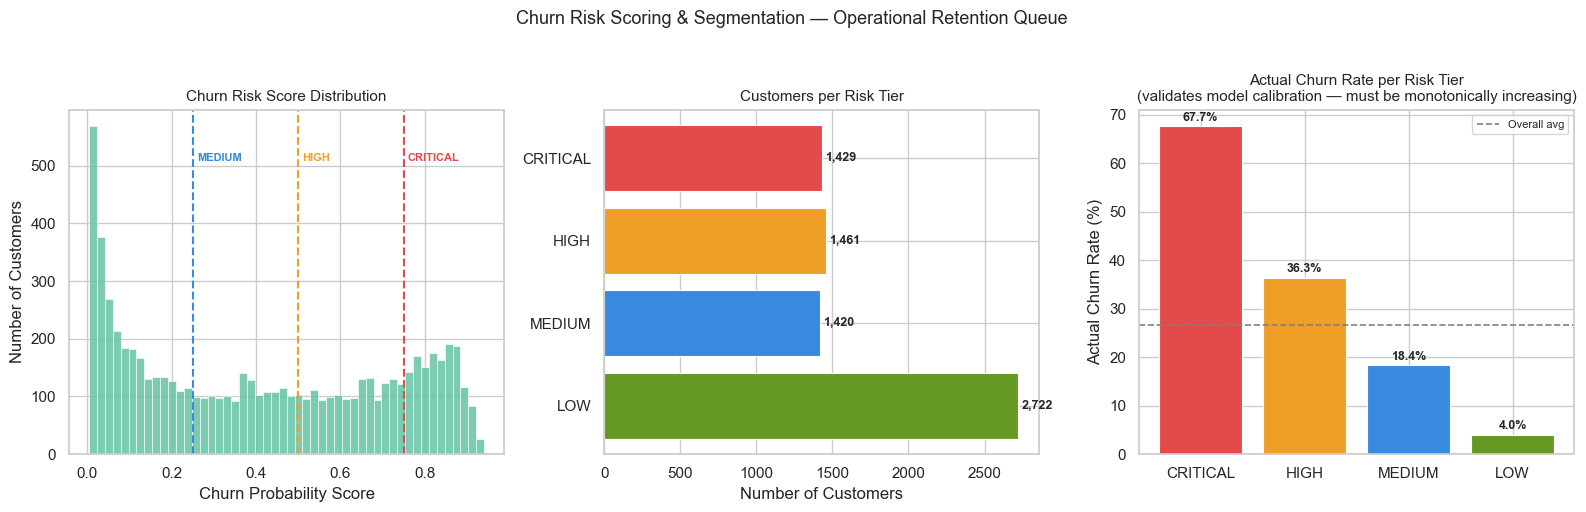

In [102]:
# Chart E1 — score distribution + tier counts + tier validation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
axes[0].hist(df["churn_prob"], bins=50, color=COLORS[0],
             edgecolor="white", linewidth=0.5, alpha=0.85)
for threshold, label, color in [
    (0.75, "CRITICAL", "#E24B4A"),
    (0.50, "HIGH",     "#EF9F27"),
    (0.25, "MEDIUM",   "#378ADD"),
]:
    axes[0].axvline(threshold, color=color, linestyle="--", linewidth=1.5)
    axes[0].text(threshold + 0.01, axes[0].get_ylim()[1] * 0.85,
                 label, color=color, fontsize=8, fontweight="bold")
axes[0].set_title("Churn Risk Score Distribution", fontsize=11)
axes[0].set_xlabel("Churn Probability Score")
axes[0].set_ylabel("Number of Customers")
 
tier_counts = risk_summary.set_index("Risk_Tier")["n_customers"].reindex(tier_order)
bars = axes[1].barh(
    tier_counts.index[::-1], tier_counts.values[::-1],
    color=[tier_colors[t] for t in tier_order[::-1]],
    edgecolor="white", linewidth=0.8,
)
for bar, val in zip(bars, tier_counts.values[::-1]):
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va="center", fontsize=9, fontweight="bold")
axes[1].set_title("Customers per Risk Tier", fontsize=11)
axes[1].set_xlabel("Number of Customers")
 
tier_churn = risk_summary.set_index("Risk_Tier")["actual_churn_rate"].reindex(tier_order)
bars = axes[2].bar(
    tier_churn.index, tier_churn.values,
    color=[tier_colors[t] for t in tier_order],
    edgecolor="white", linewidth=0.8,
)
axes[2].axhline(df["Churn_Flag"].mean() * 100, color="grey",
                linestyle="--", linewidth=1.2, label="Overall avg")
for bar, val in zip(bars, tier_churn.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold")
axes[2].set_title("Actual Churn Rate per Risk Tier\n"
                  "(validates model calibration — must be monotonically increasing)",
                  fontsize=11)
axes[2].set_ylabel("Actual Churn Rate (%)")
axes[2].legend(fontsize=8)
 
plt.suptitle("Churn Risk Scoring & Segmentation — Operational Retention Queue",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("adv_E1_risk_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()

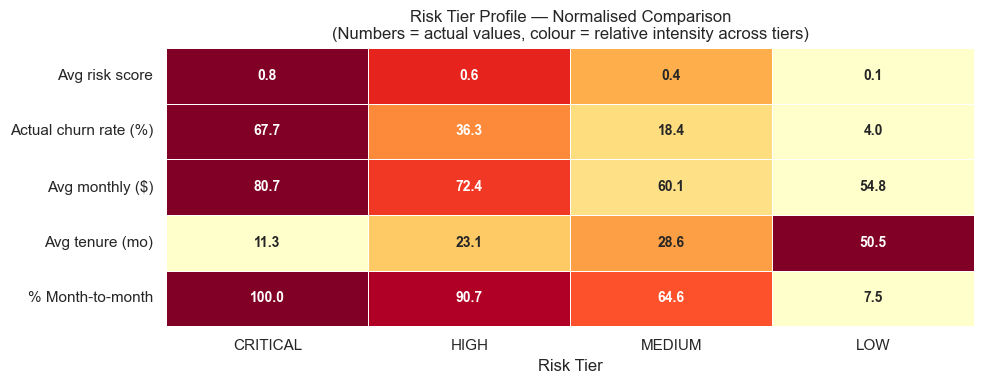


✅ All advanced analytics complete.
Charts saved: adv_A1, adv_A2, adv_B1, adv_C1–C3, adv_D1–D2, adv_E1, adv_F1–F2


In [107]:
# Chart E2 — tier profile heatmap
profile_cols   = ["avg_risk_score","actual_churn_rate",
                  "avg_monthly","avg_tenure","pct_month_to_month"]
profile_labels = ["Avg risk score","Actual churn rate (%)",
                  "Avg monthly ($)","Avg tenure (mo)","% Month-to-month"]
 
profile = risk_summary.set_index("Risk_Tier")[profile_cols].reindex(tier_order)
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
profile_norm.columns = profile_labels
profile.columns      = profile_labels
 
plt.figure(figsize=(10, 4))
sns.heatmap(
    profile_norm.T, annot=profile.T.values,
    fmt=".1f", cmap="YlOrRd", linewidths=0.5, cbar=False,
    annot_kws={"size": 10, "weight": "bold"},
)
plt.title(
    "Risk Tier Profile — Normalised Comparison\n"
    "(Numbers = actual values, colour = relative intensity across tiers)",
    fontsize=12,
)
plt.ylabel("")
plt.xlabel("Risk Tier")
plt.tight_layout()
plt.savefig("adv_E2_risk_tier_profile.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\n✅ All advanced analytics complete.")
print("Charts saved: adv_A1, adv_A2, adv_B1, adv_C1–C3, adv_D1–D2, adv_E1, adv_F1–F2")

In [112]:
df_clv[['churn_prob','CLV_Total','Segment','MonthlyCharges','Contract','tenure']].to_csv('clv_segments.csv', index=False)